In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

In [28]:
# FLARE Test Dataset
flare_results = pd.read_csv('flare_test/flare_out/flare.out.global.anc.gz', sep='\t', index_col=0)
haploHMM_results = pd.read_csv('flare_test/haploHMM_out/flare_test_global_ancestry.txt', sep='\t', index_col=0)

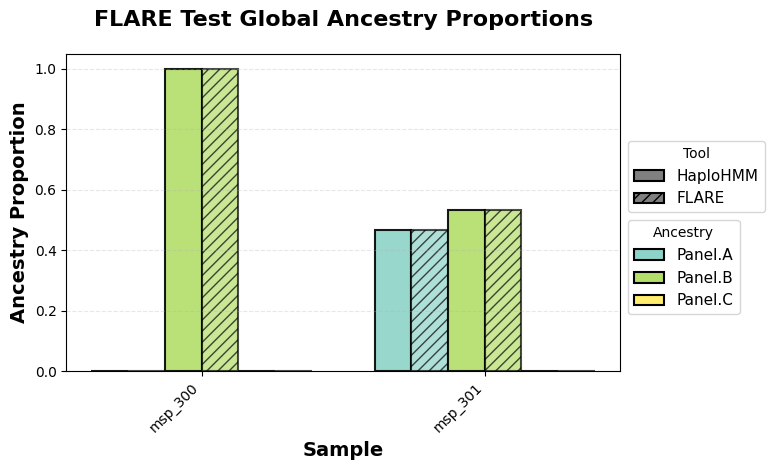

In [29]:
num_samples = len(flare_results.index)
num_ancestries = len(flare_results.columns)

# Set up colors for each ancestry
ancestry_colors = plt.cm.Set3(np.linspace(0, 1, num_ancestries))

# Create figure
fig, ax = plt.subplots()

# Bar positioning
bar_width = 0.35  # Width of each bar
x_positions = np.arange(num_samples)  # Position for each sample
spacing = 0.1  # Space between sample groups
group_width = (num_ancestries * 2 * bar_width) + spacing

# Adjust x positions to have enough space
sample_x_positions = np.arange(num_samples) * (group_width + 0.5)

# Plot bars for each ancestry
for ancestry_idx in range(num_ancestries):
    # Your tool bars (solid)
    my_x = sample_x_positions + (ancestry_idx * 2 * bar_width)
    my_heights = haploHMM_results.iloc[:, ancestry_idx].values
    
    ax.bar(my_x, my_heights, bar_width, 
            color=ancestry_colors[ancestry_idx],
            edgecolor='black', linewidth=1.5,
            label=f'{haploHMM_results.columns[ancestry_idx]} (haploHMM)' if ancestry_idx == 0 else '',
            hatch='',  # Solid
            alpha=0.9)
    
    # FLARE bars (with pattern)
    flare_x = my_x + bar_width
    flare_heights = flare_results.iloc[:, ancestry_idx].values
    
    ax.bar(flare_x, flare_heights, bar_width,
            color=ancestry_colors[ancestry_idx],
            edgecolor='black', linewidth=1.5,
            label=f'{flare_results.columns[ancestry_idx]} (FLARE)' if ancestry_idx == 0 else '',
            hatch='///',  # Diagonal stripes pattern
            alpha=0.7)

# Customize plot
ax.set_xlabel('Sample', fontsize=14, fontweight='bold')
ax.set_ylabel('Ancestry Proportion', fontsize=14, fontweight='bold')
ax.set_title('FLARE Test Global Ancestry Proportions', 
                fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels to sample names
center_positions = sample_x_positions + (num_ancestries * bar_width - bar_width/2)
ax.set_xticks(center_positions)
ax.set_xticklabels(haploHMM_results.index, rotation=45, ha='right')

# Set y-axis limits
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Create custom legend
# Color patches for ancestries
ancestry_patches = [mpatches.Patch(facecolor=ancestry_colors[i], 
                                    edgecolor='black', linewidth=1.5,
                                    label=haploHMM_results.columns[i])
                    for i in range(num_ancestries)]

# Pattern patches for tools
your_tool_patch = mpatches.Patch(facecolor='gray', edgecolor='black', 
                                    linewidth=1.5, label='HaploHMM',
                                    hatch='')
flare_patch = mpatches.Patch(facecolor='gray', edgecolor='black',
                                linewidth=1.5, label='FLARE',
                                hatch='///')

# Create legend with two columns
leg1 = ax.legend(handles=ancestry_patches, title='Ancestry', 
                    frameon=True, fontsize=11, bbox_to_anchor=(1, 0.5))
ax.add_artist(leg1)

leg2 = ax.legend(handles=[your_tool_patch, flare_patch], title='Tool',
                    frameon=True, fontsize=11, bbox_to_anchor=(1, 0.75))

plt.tight_layout()
plt.show()

In [30]:
# 1000Genomes Dataset
flare_results = pd.read_csv('1000genomes/flare_1000genomes/small_subset.global.anc.gz', sep='\t', index_col=0)
haploHMM_results = pd.read_csv('1000genomes/haploHMM_1000genomes/small_subset_global_ancestry.txt', sep='\t', index_col=0)

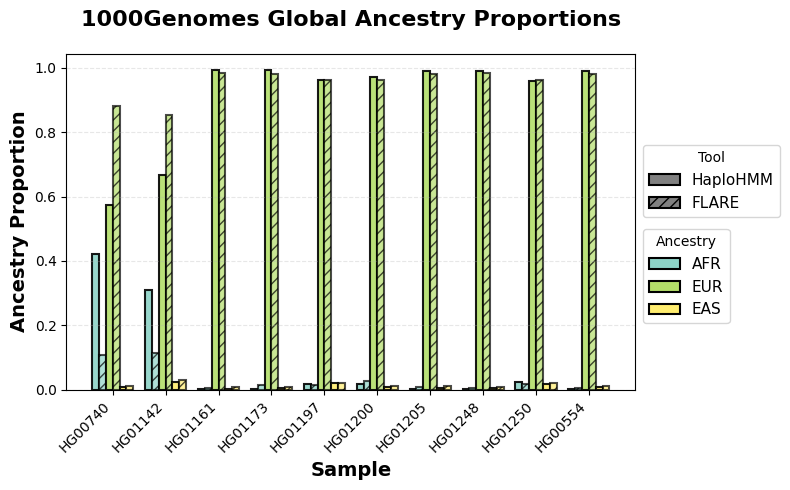

In [35]:
num_samples = len(flare_results.index)
num_ancestries = len(flare_results.columns)

# Set up colors for each ancestry
ancestry_colors = plt.cm.Set3(np.linspace(0, 1, num_ancestries))

# Create figure
fig, ax = plt.subplots(figsize=(8,5))

# Bar positioning
bar_width = 0.35  # Width of each bar
x_positions = np.arange(num_samples)  # Position for each sample
spacing = 0.1  # Space between sample groups
group_width = (num_ancestries * 2 * bar_width) + spacing

# Adjust x positions to have enough space
sample_x_positions = np.arange(num_samples) * (group_width + 0.5)

# Plot bars for each ancestry
for ancestry_idx in range(num_ancestries):
    # Your tool bars (solid)
    my_x = sample_x_positions + (ancestry_idx * 2 * bar_width)
    my_heights = haploHMM_results.iloc[:, ancestry_idx].values
    
    ax.bar(my_x, my_heights, bar_width, 
            color=ancestry_colors[ancestry_idx],
            edgecolor='black', linewidth=1.5,
            label=f'{haploHMM_results.columns[ancestry_idx]} (haploHMM)' if ancestry_idx == 0 else '',
            hatch='',  # Solid
            alpha=0.9)
    
    # FLARE bars (with pattern)
    flare_x = my_x + bar_width
    flare_heights = flare_results.iloc[:, ancestry_idx].values
    
    ax.bar(flare_x, flare_heights, bar_width,
            color=ancestry_colors[ancestry_idx],
            edgecolor='black', linewidth=1.5,
            label=f'{flare_results.columns[ancestry_idx]} (FLARE)' if ancestry_idx == 0 else '',
            hatch='///',  # Diagonal stripes pattern
            alpha=0.7)

# Customize plot
ax.set_xlabel('Sample', fontsize=14, fontweight='bold')
ax.set_ylabel('Ancestry Proportion', fontsize=14, fontweight='bold')
ax.set_title('1000Genomes Global Ancestry Proportions', 
                fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels to sample names
center_positions = sample_x_positions + (num_ancestries * bar_width - bar_width/2)
ax.set_xticks(center_positions)
ax.set_xticklabels(haploHMM_results.index, rotation=45, ha='right')

# Set y-axis limits
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Create custom legend
# Color patches for ancestries
ancestry_patches = [mpatches.Patch(facecolor=ancestry_colors[i], 
                                    edgecolor='black', linewidth=1.5,
                                    label=haploHMM_results.columns[i])
                    for i in range(num_ancestries)]

# Pattern patches for tools
your_tool_patch = mpatches.Patch(facecolor='gray', edgecolor='black', 
                                    linewidth=1.5, label='HaploHMM',
                                    hatch='')
flare_patch = mpatches.Patch(facecolor='gray', edgecolor='black',
                                linewidth=1.5, label='FLARE',
                                hatch='///')

# Create legend with two columns
leg1 = ax.legend(handles=ancestry_patches, title='Ancestry', 
                    frameon=True, fontsize=11, bbox_to_anchor=(1, 0.5))
ax.add_artist(leg1)

leg2 = ax.legend(handles=[your_tool_patch, flare_patch], title='Tool',
                    frameon=True, fontsize=11, bbox_to_anchor=(1, 0.75))

plt.tight_layout()
plt.show()